# Variational Autoencoders — Learning to Generate Handwritten Digits

In the previous two notebooks we built classifiers: networks that map an image to a class label. Now we turn the problem around. Instead of asking *"what digit is this?"*, we ask *"can the network learn enough about the structure of handwritten digits to **invent new ones**?"*

A **Variational Autoencoder (VAE)** does this by learning a compact, probabilistic description of the data. It has two halves:

- **Encoder** — compresses a 28×28 image (784 numbers) down to a tiny *latent vector* (just 2 numbers here). Think of it as finding the essential "coordinates" of a digit in an abstract style-space.
- **Decoder** — takes a latent vector and reconstructs a full image from it.

Once trained, we can **ignore the encoder entirely** and sample random latent vectors, feeding them straight into the decoder to produce brand-new synthetic digits that were never in the training set.

By the end of this notebook you will have:
- Understood the encoder–decoder paradigm and the reparameterization trick
- Built a VAE in PyTorch and understood its unusual loss function
- Visualised the 2-dimensional latent space and seen how digit classes organise themselves
- Generated synthetic MNIST digits using **only the decoder** (no real images involved)
- Interpolated smoothly between two real digits by walking through the latent space
- Compared how the latent space dimension affects reconstruction quality

## 1. Imports and Setup

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.2.2


## 2. Load MNIST

The preprocessing is identical to the previous notebooks. One important conceptual difference: **the target is now the image itself, not the class label**. We are training the network to reconstruct its own input — no human-provided labels are used at all. This is called *self-supervised* or *unsupervised* learning.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

print(f"Training images : {len(train_dataset):,}")
print(f"Test images     : {len(test_dataset):,}")
print(f"Batches per epoch: {len(train_loader)}")

Training images : 60,000
Test images     : 10,000
Batches per epoch: 469


## 3. Why a VAE? The Physics Intuition

### Compression and the latent space

Suppose you have a library of stellar spectra — each spectrum is a vector of flux values at, say, 10,000 wavelengths. You notice that most spectra can be described well by just a handful of numbers: effective temperature, surface gravity, and metallicity. A standard autoencoder (without the "variational" part) would be like finding the nonlinear equivalent of PCA: compress 10,000 numbers down to 3 without losing much information, and reconstruct the full spectrum from those 3 numbers.

The VAE does something more ambitious: it learns a **probability distribution** over the compressed representation, not just a single point. This turns out to be essential for generation.

### Why plain autoencoders can't generate

A plain (non-variational) autoencoder learns to map each training image to some specific point in the latent space, and map that point back to the image. But the points can be scattered irregularly — there is no guarantee that the *space between* points corresponds to anything meaningful. If you sample a random latent vector, the decoder may produce garbage because it has never seen anything near that point.

### The variational solution

The VAE fixes this by forcing the encoder to output a **Gaussian distribution** — a mean vector $\boldsymbol{\mu}$ and a variance vector $\boldsymbol{\sigma}^2$ — rather than a single point. It then draws the latent vector $\mathbf{z}$ by sampling from that Gaussian.

An additional penalty term in the loss (the **KL divergence**) pushes every encoder distribution toward a standard normal $\mathcal{N}(\mathbf{0}, \mathbf{I})$. This is a Bayesian prior: we are saying *"in the absence of other information, the latent code should look like standard Gaussian noise."* The prior regularises the latent space, filling in the gaps between training points.

The practical consequence: after training, we can sample $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decode it into a realistic-looking digit — the latent space is now a smooth, well-populated manifold rather than a sparse cloud of isolated points.

| | Plain Autoencoder | VAE |
|---|---|---|
| Encoder output | single point $\mathbf{z}$ | distribution $(\boldsymbol{\mu}, \boldsymbol{\sigma}^2)$ |
| Latent space structure | uncontrolled | regularised toward $\mathcal{N}(\mathbf{0}, \mathbf{I})$ |
| Can generate new samples? | not reliably | yes |
| Extra loss term | none | KL divergence |

## 4. Architecture

### 4a. ASCII diagram

```
                   ENCODER                     REPARAMETERISE       DECODER

Input    Linear+ReLU    Linear         z = μ + σ·ε      Linear+ReLU    Output
784   →     512      →  μ (2)    →        z (2)      →     512      →   784
                     →  logσ²(2)  ε ~ N(0,1)
                       ~800k parameters total
```

The encoder outputs **two** vectors of length 2:
- $\boldsymbol{\mu}$ (mu) — the *mean* of the Gaussian posterior for this image
- $\log \boldsymbol{\sigma}^2$ (logvar) — the *log-variance*. We output log σ² rather than σ directly because it can take any real value, while σ must be positive. The network is free to learn any real number, and we convert to σ via `σ = exp(0.5 * logvar)`.

The **reparameterization trick** draws a sample $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\varepsilon}$ where $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$. This factored form moves the randomness into a fixed input $\boldsymbol{\varepsilon}$ that PyTorch does not differentiate through, allowing gradients to flow back through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ as usual.

### 4b. Matplotlib architecture diagram

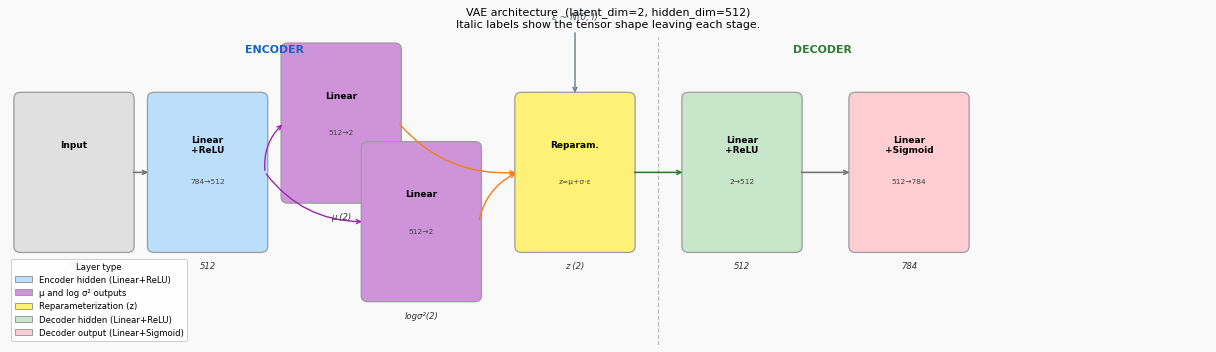

In [3]:
def draw_vae_architecture():
    fig, ax = plt.subplots(figsize=(17, 5))
    ax.set_xlim(0, 18)
    ax.set_ylim(0, 5)
    ax.axis('off')
    fig.patch.set_facecolor('#f9f9f9')
    ax.set_facecolor('#f9f9f9')

    # Each entry: (label, sub-label, shape, x-centre, colour)
    boxes = [
        ("Input",            "",           "784",    1.0,  '#e0e0e0'),
        ("Linear\n+ReLU",    "784→512",    "512",    3.0,  '#bbdefb'),
        ("Linear",           "512→2",      "μ (2)",  5.0,  '#ce93d8'),
        ("Linear",           "512→2",      "logσ²(2)",6.2, '#ce93d8'),
        ("Reparam.",         "z=μ+σ·ε",   "z (2)",  8.5,  '#fff176'),
        ("Linear\n+ReLU",    "2→512",      "512",   11.0,  '#c8e6c9'),
        ("Linear\n+Sigmoid", "512→784",    "784",   13.5,  '#ffcdd2'),
    ]

    box_w, box_h, y_c = 1.6, 2.4, 2.8

    # The encoder hidden layer is shared between mu and logvar branches;
    # draw it slightly taller to hint at the fork.
    shared_x = 3.0

    for i, (label, sub, shape, x, col) in enumerate(boxes):
        # mu and logvar boxes sit at different y heights to show the fork
        y = y_c
        if label == "Linear" and shape.startswith("μ"):
            y = y_c + 0.8
        elif label == "Linear" and shape.startswith("log"):
            y = y_c - 0.8

        rect = mpatches.FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.1",
            facecolor=col, edgecolor='#9e9e9e', linewidth=1.3, zorder=2
        )
        ax.add_patch(rect)
        ax.text(x, y + 0.45, label, ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=3)
        if sub:
            ax.text(x, y - 0.15, sub, ha='center', va='center',
                    fontsize=7.5, color='#444', zorder=3)
        ax.text(x, y - box_h / 2 - 0.25, shape,
                ha='center', va='top', fontsize=8.5,
                color='#333', style='italic', zorder=3)

    # Arrows: Input → shared hidden
    ax.annotate('', xy=(shared_x - box_w/2 - 0.06, y_c),
                xytext=(1.0 + box_w/2 + 0.06, y_c),
                arrowprops=dict(arrowstyle='->', color='#757575', lw=1.6), zorder=2)

    # Shared hidden → mu branch (fork up)
    ax.annotate('', xy=(5.0 - box_w/2 - 0.06, y_c + 0.8),
                xytext=(shared_x + box_w/2 + 0.06, y_c),
                arrowprops=dict(arrowstyle='->', color='#9c27b0', lw=1.4,
                                connectionstyle='arc3,rad=-0.25'), zorder=2)

    # Shared hidden → logvar branch (fork down)
    ax.annotate('', xy=(6.2 - box_w/2 - 0.06, y_c - 0.8),
                xytext=(shared_x + box_w/2 + 0.06, y_c),
                arrowprops=dict(arrowstyle='->', color='#9c27b0', lw=1.4,
                                connectionstyle='arc3,rad=0.25'), zorder=2)

    # mu → reparam
    ax.annotate('', xy=(8.5 - box_w/2 - 0.06, y_c),
                xytext=(5.0 + box_w/2 + 0.06, y_c + 0.8),
                arrowprops=dict(arrowstyle='->', color='#f57f17', lw=1.4,
                                connectionstyle='arc3,rad=0.25'), zorder=2)

    # logvar → reparam
    ax.annotate('', xy=(8.5 - box_w/2 - 0.06, y_c),
                xytext=(6.2 + box_w/2 + 0.06, y_c - 0.8),
                arrowprops=dict(arrowstyle='->', color='#f57f17', lw=1.4,
                                connectionstyle='arc3,rad=-0.25'), zorder=2)

    # ε ~ N(0,I) input to reparam
    ax.annotate('', xy=(8.5, y_c + box_h/2 + 0.06),
                xytext=(8.5, y_c + box_h/2 + 1.1),
                arrowprops=dict(arrowstyle='->', color='#607d8b', lw=1.4), zorder=2)
    ax.text(8.5, y_c + box_h/2 + 1.25, 'ε ~ N(0, I)',
            ha='center', va='bottom', fontsize=9, color='#455a64', style='italic')

    # reparam → decoder hidden
    ax.annotate('', xy=(11.0 - box_w/2 - 0.06, y_c),
                xytext=(8.5 + box_w/2 + 0.06, y_c),
                arrowprops=dict(arrowstyle='->', color='#2e7d32', lw=1.6), zorder=2)

    # decoder hidden → output
    ax.annotate('', xy=(13.5 - box_w/2 - 0.06, y_c),
                xytext=(11.0 + box_w/2 + 0.06, y_c),
                arrowprops=dict(arrowstyle='->', color='#757575', lw=1.6), zorder=2)

    # Dashed vertical line separating encoder from decoder
    ax.axvline(9.75, color='#bdbdbd', lw=1.2, linestyle='--', zorder=1)
    ax.text(4.0, 4.75, 'ENCODER', ha='center', fontsize=11,
            color='#1565c0', fontweight='bold')
    ax.text(12.2, 4.75, 'DECODER', ha='center', fontsize=11,
            color='#2e7d32', fontweight='bold')

    legend_items = [
        mpatches.Patch(facecolor='#bbdefb', edgecolor='#9e9e9e', label='Encoder hidden (Linear+ReLU)'),
        mpatches.Patch(facecolor='#ce93d8', edgecolor='#9e9e9e', label='μ and log σ² outputs'),
        mpatches.Patch(facecolor='#fff176', edgecolor='#9e9e9e', label='Reparameterization (z)'),
        mpatches.Patch(facecolor='#c8e6c9', edgecolor='#9e9e9e', label='Decoder hidden (Linear+ReLU)'),
        mpatches.Patch(facecolor='#ffcdd2', edgecolor='#9e9e9e', label='Decoder output (Linear+Sigmoid)'),
    ]
    ax.legend(handles=legend_items, loc='lower left', fontsize=8.5,
              framealpha=0.95, edgecolor='#ccc', title='Layer type', title_fontsize=8.5)

    ax.set_title(
        "VAE architecture  (latent_dim=2, hidden_dim=512)\n"
        "Italic labels show the tensor shape leaving each stage.",
        fontsize=11, pad=10
    )
    plt.tight_layout()
    plt.show()

draw_vae_architecture()

## 5. Define the Encoder

The encoder maps a flattened image (784 numbers) to the parameters of a Gaussian distribution: a mean vector $\boldsymbol{\mu}$ and a log-variance vector $\log \boldsymbol{\sigma}^2$, each of length `latent_dim`.

We output `logvar` (log-variance) rather than $\sigma$ directly for a numerical reason: $\sigma$ must be strictly positive, which would require a constrained output (e.g. a softplus activation). Log-variance can be any real number, which is easier for the network to learn. We convert back to $\sigma$ later via $\sigma = \exp\!\left(\tfrac{1}{2} \log \sigma^2\right)$.

In [4]:
class Encoder(nn.Module):
    """
    Maps a flattened MNIST image (784) to Gaussian parameters (mu, logvar).

    Parameters
    ----------
    latent_dim : int  - dimension of the latent space z
    hidden_dim : int  - width of the hidden layer
    """
    def __init__(self, latent_dim=2, hidden_dim=512):
        super(Encoder, self).__init__()

        # Shared trunk: one hidden layer takes raw pixels to an intermediate representation
        self.shared = nn.Sequential(
            nn.Linear(784, hidden_dim),
            nn.ReLU(),
        )

        # Two separate linear heads branch off the shared trunk.
        # There are no activation functions on these heads: mu can be
        # any real number, and logvar can also be any real number.
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = x.view(-1, 784)          # flatten: (batch, 1, 28, 28) -> (batch, 784)
        h = self.shared(x)           # shared representation, shape (batch, hidden_dim)
        mu     = self.fc_mu(h)       # mean of the posterior, shape (batch, latent_dim)
        logvar = self.fc_logvar(h)   # log-variance, shape (batch, latent_dim)
        return mu, logvar


enc = Encoder(latent_dim=2, hidden_dim=512)
n_enc = sum(p.numel() for p in enc.parameters())
print("Encoder:")
print(enc)
print(f"\nEncoder parameters: {n_enc:,}")

Encoder:
Encoder(
  (shared): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=512, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=512, out_features=2, bias=True)
)

Encoder parameters: 403,972


## 6. Define the Decoder

The decoder is a mirror image of the encoder: it maps a latent vector $\mathbf{z}$ back to a full 784-pixel image.

The final activation is a **sigmoid**, which squashes the output to $[0, 1]$ — the same range as the un-normalised MNIST pixel values. This is required for Binary Cross-Entropy loss, which we use to measure reconstruction quality.

> **Note on normalisation:** Our data was normalised to zero mean and unit standard deviation, so raw pixel values are not in $[0,1]$. We handle this by un-normalising the inputs before computing the reconstruction loss — see the loss function cell for details.

In [5]:
class Decoder(nn.Module):
    """
    Maps a latent vector z back to a flattened MNIST image in [0, 1].

    Parameters
    ----------
    latent_dim : int  - dimension of the latent space z
    hidden_dim : int  - width of the hidden layer
    """
    def __init__(self, latent_dim=2, hidden_dim=512):
        super(Decoder, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),
            nn.Sigmoid(),   # output in [0, 1] — needed for BCE reconstruction loss
        )

    def forward(self, z):
        # z shape: (batch, latent_dim)
        # output shape: (batch, 784)  — flattened image in [0, 1]
        return self.network(z)


dec = Decoder(latent_dim=2, hidden_dim=512)
n_dec = sum(p.numel() for p in dec.parameters())
print("Decoder:")
print(dec)
print(f"\nDecoder parameters: {n_dec:,}")

Decoder:
Decoder(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Decoder parameters: 403,728


## 7. Define the VAE and the Reparameterization Trick

The VAE class wires the encoder and decoder together and implements the **reparameterization trick**.

### Why can't we just sample directly?

During training we need to backpropagate gradients from the loss all the way back through $\mathbf{z}$ to the encoder parameters $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$. But $\mathbf{z}$ is drawn from a random distribution — and you cannot differentiate through a random sample directly.

### The trick

Instead of sampling $\mathbf{z} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\sigma}^2 \mathbf{I})$ directly, we write:

$$\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

The randomness is now in $\boldsymbol{\varepsilon}$, which is a **fixed external input** — just noise drawn before the forward pass. Gradients can flow freely through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ because those are ordinary differentiable operations (addition and multiplication). The $\boldsymbol{\varepsilon}$ term is treated as a constant with respect to differentiation.

A physical analogy: in Monte Carlo integration you sometimes need the integral of $f(x)$ over a distribution $p(x)$. If you fix the random draws $\{x_i\}$ at the start and then vary the parameters of $f$, you can differentiate the integral estimate with respect to $f$'s parameters — the randomness is factored out.

In [6]:
class VAE(nn.Module):
    """
    Variational Autoencoder combining an Encoder and Decoder.

    Parameters
    ----------
    latent_dim : int  - dimension of the latent space
    hidden_dim : int  - width of hidden layers in both encoder and decoder
    """
    def __init__(self, latent_dim=2, hidden_dim=512):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim, hidden_dim)
        self.decoder = Decoder(latent_dim, hidden_dim)
        self.latent_dim = latent_dim

    def reparameterise(self, mu, logvar):
        """
        Sample z = mu + sigma * eps, where eps ~ N(0, I).
        This keeps gradients flowing back to mu and logvar.
        """
        # Convert log-variance to standard deviation:
        # logvar = log(sigma^2), so sigma = exp(0.5 * logvar)
        sigma = torch.exp(0.5 * logvar)

        # randn_like creates a standard normal tensor with the same
        # shape and device as sigma — no extra .to() call needed.
        eps = torch.randn_like(sigma)

        return mu + sigma * eps   # shape: (batch, latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterise(mu, logvar)
        x_recon    = self.decoder(z)   # shape: (batch, 784), values in [0, 1]
        return x_recon, mu, logvar

    def generate(self, n_samples=16):
        """
        Generate new images using the decoder only — no encoder, no real images.
        Samples z directly from the prior N(0, I).
        """
        with torch.no_grad():
            z = torch.randn(n_samples, self.latent_dim)
            return self.decoder(z)   # shape: (n_samples, 784)

    def encode(self, x):
        """Return the latent mean for a batch of images (for visualisation)."""
        with torch.no_grad():
            mu, _ = self.encoder(x)
        return mu


vae = VAE(latent_dim=2, hidden_dim=512)
n_total = sum(p.numel() for p in vae.parameters())
print(f"Total VAE parameters: {n_total:,}")
print(f"  Encoder: {sum(p.numel() for p in vae.encoder.parameters()):,}")
print(f"  Decoder: {sum(p.numel() for p in vae.decoder.parameters()):,}")

Total VAE parameters: 807,700
  Encoder: 403,972
  Decoder: 403,728


## 8. The Loss Function: ELBO

The VAE optimises the **Evidence Lower BOund (ELBO)**, which has two terms:

$$\mathcal{L} = \underbrace{\mathbb{E}_{\mathbf{z}}\left[\log p(\mathbf{x} | \mathbf{z})\right]}_{\text{reconstruction}} - \underbrace{D_{\mathrm{KL}}\left[q(\mathbf{z}|\mathbf{x}) \,\|\, p(\mathbf{z})\right]}_{\text{KL regularisation}}$$

We **maximise** the ELBO, which is equivalent to **minimising** the negative ELBO:

$$\mathcal{L}_{\text{loss}} = \underbrace{\text{BCE}(\hat{\mathbf{x}}, \mathbf{x})}_{\text{reconstruction loss}} + \underbrace{D_{\mathrm{KL}}}_{\text{KL loss}}$$

### Reconstruction loss
Binary Cross-Entropy between the decoder's output $\hat{\mathbf{x}}$ (a probability per pixel) and the original image $\mathbf{x}$ (treated as pixel intensity in $[0, 1]$). This is exactly $-\log p(\mathbf{x}|\mathbf{z})$ under a Bernoulli pixel model. Think of it like a likelihood: large when the reconstruction is far from the original, small when they match.

### KL divergence
For a Gaussian encoder $q(\mathbf{z}|\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \mathrm{diag}(\boldsymbol{\sigma}^2))$ and standard normal prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$, the KL has a closed-form analytic expression:

$$D_{\mathrm{KL}} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

This is exactly zero when $\boldsymbol{\mu} = \mathbf{0}$ and $\boldsymbol{\sigma} = \mathbf{1}$ (encoder output matches the prior). It grows whenever the encoder concentrates its posterior tightly around some non-zero mean — which is what the encoder wants to do for accurate reconstruction. The two terms therefore pull in opposite directions, and the network learns a balance.

We sum the loss over all pixels and latent dimensions, then average over the batch.

In [7]:
# MNIST was normalised to mean=0.1307, std=0.3081.
# The decoder outputs values in [0, 1] (before normalisation).
# To compute BCE between the decoder output and the original image,
# we need both in the same space — so we un-normalise the input images.
MNIST_MEAN = 0.1307
MNIST_STD  = 0.3081

def unnormalise(x):
    """Convert normalised MNIST tensors back to [0, 1] pixel values."""
    return x * MNIST_STD + MNIST_MEAN


def vae_loss(x_recon, x_orig, mu, logvar):
    """
    Compute the VAE loss = reconstruction loss + KL divergence.

    Parameters
    ----------
    x_recon : (batch, 784)  decoder output, in [0, 1]
    x_orig  : (batch, 1, 28, 28)  normalised input images
    mu      : (batch, latent_dim)  encoder mean
    logvar  : (batch, latent_dim)  encoder log-variance

    Returns
    -------
    total_loss, recon_loss, kl_loss  (all scalar tensors, averaged over batch)
    """
    batch_size = x_orig.size(0)

    # Un-normalise the target so both sides are in [0, 1]
    x_target = unnormalise(x_orig).view(batch_size, -1)   # (batch, 784)

    # Reconstruction loss: Binary Cross-Entropy summed over pixels, averaged over batch.
    # reduction='sum' gives sum over all pixels and batch elements;
    # we then divide by batch_size to get an average per image.
    recon_loss = F.binary_cross_entropy(x_recon, x_target,
                                        reduction='sum') / batch_size

    # KL divergence: closed-form for Gaussian vs. standard normal.
    # Summed over latent dimensions, averaged over batch.
    # -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss


print("Loss function defined.")
print("It returns: (total_loss, reconstruction_loss, kl_loss)")

Loss function defined.
It returns: (total_loss, reconstruction_loss, kl_loss)


## 9. Train the VAE

We train for 20 epochs. Two loss components are tracked separately:
- **Reconstruction loss** — starts high and falls as the network learns to compress and decompress images.
- **KL loss** — starts near zero (the encoder hasn't learned anything yet, so its output is close to the prior) and rises as the encoder develops informative structure, then stabilises when the two terms reach an equilibrium.

Training takes roughly 5–10 minutes on a CPU.

Epoch  1/20  |  Total: 182.6  Recon: 176.1  KL: 6.46  | 13.9s
Epoch  2/20  |  Total: 164.8  Recon: 159.3  KL: 5.49  | 14.1s
Epoch  3/20  |  Total: 161.3  Recon: 155.8  KL: 5.54  | 15.4s
Epoch  4/20  |  Total: 159.3  Recon: 153.7  KL: 5.61  | 14.0s
Epoch  5/20  |  Total: 157.7  Recon: 152.1  KL: 5.68  | 14.0s
Epoch  6/20  |  Total: 156.5  Recon: 150.8  KL: 5.73  | 13.5s
Epoch  7/20  |  Total: 155.6  Recon: 149.8  KL: 5.78  | 13.5s
Epoch  8/20  |  Total: 154.7  Recon: 148.9  KL: 5.83  | 13.6s
Epoch  9/20  |  Total: 154.0  Recon: 148.2  KL: 5.85  | 13.6s
Epoch 10/20  |  Total: 153.5  Recon: 147.6  KL: 5.88  | 13.6s
Epoch 11/20  |  Total: 153.0  Recon: 147.1  KL: 5.91  | 13.6s
Epoch 12/20  |  Total: 152.5  Recon: 146.5  KL: 5.95  | 13.7s
Epoch 13/20  |  Total: 152.1  Recon: 146.2  KL: 5.97  | 13.8s
Epoch 14/20  |  Total: 151.8  Recon: 145.8  KL: 5.99  | 13.7s
Epoch 15/20  |  Total: 151.4  Recon: 145.4  KL: 6.02  | 13.8s
Epoch 16/20  |  Total: 151.2  Recon: 145.1  KL: 6.04  | 13.8s
Epoch 17

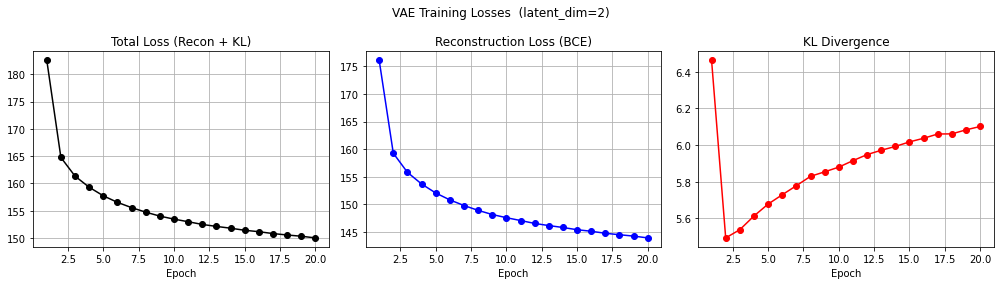

In [8]:
import time

def train_vae(model, train_loader, n_epochs=20, lr=1e-3):
    """
    Train the VAE and return per-epoch losses.

    Returns
    -------
    total_losses, recon_losses, kl_losses : lists of per-epoch averages
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    total_losses, recon_losses, kl_losses = [], [], []

    for epoch in range(n_epochs):
        t0 = time.time()
        model.train()
        epoch_total = epoch_recon = epoch_kl = 0.0

        for images, _ in train_loader:   # labels are unused
            optimizer.zero_grad()
            x_recon, mu, logvar = model(images)
            loss, recon, kl = vae_loss(x_recon, images, mu, logvar)
            loss.backward()
            optimizer.step()

            epoch_total += loss.item()
            epoch_recon += recon.item()
            epoch_kl    += kl.item()

        n = len(train_loader)
        total_losses.append(epoch_total / n)
        recon_losses.append(epoch_recon / n)
        kl_losses.append(epoch_kl / n)

        print(f"Epoch {epoch+1:2d}/{n_epochs}  |  "
              f"Total: {epoch_total/n:.1f}  "
              f"Recon: {epoch_recon/n:.1f}  "
              f"KL: {epoch_kl/n:.2f}  "
              f"| {time.time()-t0:.1f}s")

    return total_losses, recon_losses, kl_losses


vae = VAE(latent_dim=2, hidden_dim=512)
total_losses, recon_losses, kl_losses = train_vae(vae, train_loader, n_epochs=20)

# Plot the three loss components over training
epochs = range(1, 21)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs, total_losses, 'k-o')
axes[0].set_title('Total Loss (Recon + KL)')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)

axes[1].plot(epochs, recon_losses, 'b-o')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

axes[2].plot(epochs, kl_losses, 'r-o')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

plt.suptitle('VAE Training Losses  (latent_dim=2)', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Visualise Reconstructions

We pass test images through the full VAE (encode → sample z → decode) and compare the reconstructions to the originals.

With only 2 latent dimensions, the reconstructions will look somewhat blurry — the network is forced to encode *all* the information about a digit into just two numbers. This is a deliberate constraint: a 2D latent space lets us visualise it directly as a 2D scatter plot (next section). The trade-off between compression ratio and reconstruction fidelity is one of the core design choices in any autoencoder.

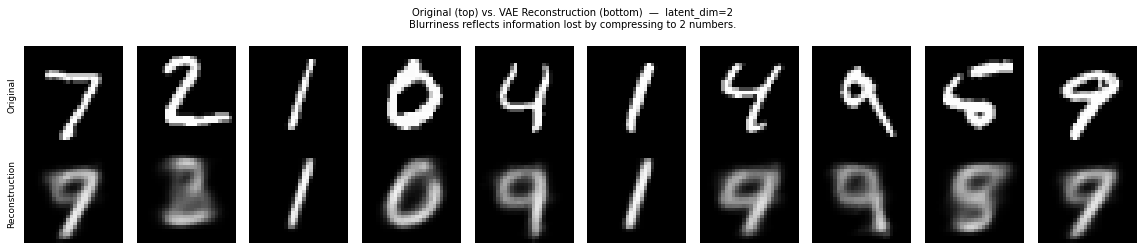

In [9]:
def show_reconstructions(model, dataset, n=8):
    """
    Display n original images (top row) alongside their VAE reconstructions (bottom row).
    """
    model.eval()
    images = torch.stack([dataset[i][0] for i in range(n)])   # (n, 1, 28, 28)

    with torch.no_grad():
        x_recon, _, _ = model(images)   # x_recon shape: (n, 784)

    x_recon = x_recon.view(n, 28, 28).numpy()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.6, 3.5))

    for i in range(n):
        # Top row: original (un-normalised so pixel values are in [0, 1])
        orig = unnormalise(images[i]).squeeze().numpy()
        axes[0, i].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')

        # Bottom row: reconstruction
        axes[1, i].imshow(x_recon[i], cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')

    # axis('off') suppresses set_ylabel, so use text() with axes-relative coords instead
    axes[0, 0].text(-0.08, 0.5, 'Original',
                    transform=axes[0, 0].transAxes,
                    fontsize=9, ha='right', va='center', rotation=90)
    axes[1, 0].text(-0.08, 0.5, 'Reconstruction',
                    transform=axes[1, 0].transAxes,
                    fontsize=9, ha='right', va='center', rotation=90)

    plt.suptitle(
        f'Original (top) vs. VAE Reconstruction (bottom)  —  latent_dim=2\n'
        f'Blurriness reflects information lost by compressing to 2 numbers.',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


show_reconstructions(vae, test_dataset, n=10)

## 11. Explore the Latent Space

One of the payoffs of using a 2D latent space is that we can plot it directly. We encode all 10,000 test images and plot the mean $\boldsymbol{\mu}$ for each image, coloured by its true digit class.

The KL term pushes the entire distribution toward $\mathcal{N}(\mathbf{0}, \mathbf{I})$, so all points should cluster near the origin. At the same time, the reconstruction term pushes images of different classes to have different latent codes so the decoder can tell them apart. The result is a structured partition of the unit-ish disk around the origin: different digit classes occupy different regions, with overlaps at the boundaries where similar-looking digits live (e.g. 4 and 9, or 3 and 8).

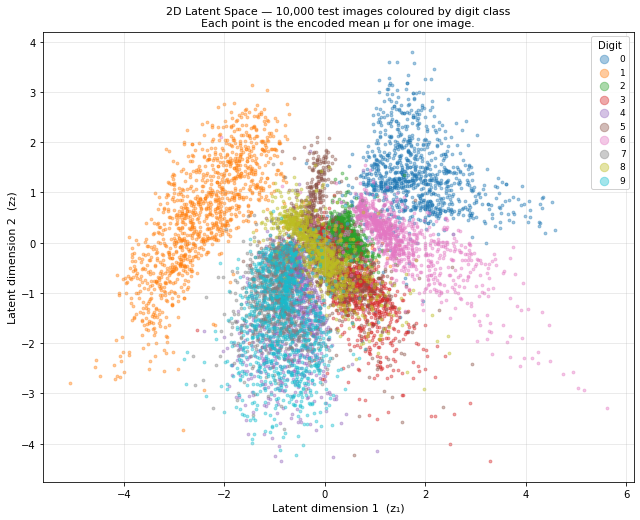

In [10]:
def plot_latent_space(model, dataset, n_points=10000):
    """
    Encode test images to 2D latent coordinates and scatter-plot by digit class.
    """
    model.eval()
    all_mu     = []
    all_labels = []

    # Process the dataset in batches to avoid running out of memory
    loader = DataLoader(dataset, batch_size=500, shuffle=False)
    with torch.no_grad():
        for images, labels in loader:
            mu, _ = model.encoder(images)
            all_mu.append(mu.numpy())
            all_labels.append(labels.numpy())
            if sum(len(m) for m in all_mu) >= n_points:
                break

    all_mu     = np.concatenate(all_mu,     axis=0)[:n_points]
    all_labels = np.concatenate(all_labels, axis=0)[:n_points]

    fig, ax = plt.subplots(figsize=(9, 8))
    cmap = plt.cm.get_cmap('tab10', 10)

    for digit in range(10):
        mask = all_labels == digit
        ax.scatter(all_mu[mask, 0], all_mu[mask, 1],
                   s=8, alpha=0.4, color=cmap(digit), label=str(digit))

    ax.set_xlabel('Latent dimension 1  (z₁)', fontsize=11)
    ax.set_ylabel('Latent dimension 2  (z₂)', fontsize=11)
    ax.set_title(
        f'2D Latent Space — {n_points:,} test images coloured by digit class\n'
        'Each point is the encoded mean μ for one image.',
        fontsize=11
    )
    ax.legend(title='Digit', markerscale=3, fontsize=9,
              loc='upper right', framealpha=0.9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_latent_space(vae, test_dataset)

## 12. Generate New Digits — Decoder Only

This is the core generative capability of the VAE. We **bypass the encoder entirely**: there are no real images involved at all. Instead, we sample latent vectors directly from the prior $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and pass them through the decoder.

Because the KL term during training forced the encoder distributions to look like $\mathcal{N}(\mathbf{0}, \mathbf{I})$, the decoder has learned to turn samples from that distribution into realistic digit images. The encoder was just a training scaffold — at generation time, it is discarded.

We also show a **2D grid scan** of the latent space: we sweep $z_1$ and $z_2$ across a regular grid and decode each point. This directly visualises what the decoder has learned to associate with each region of the latent space — you should see smooth transitions between digit identities and styles.

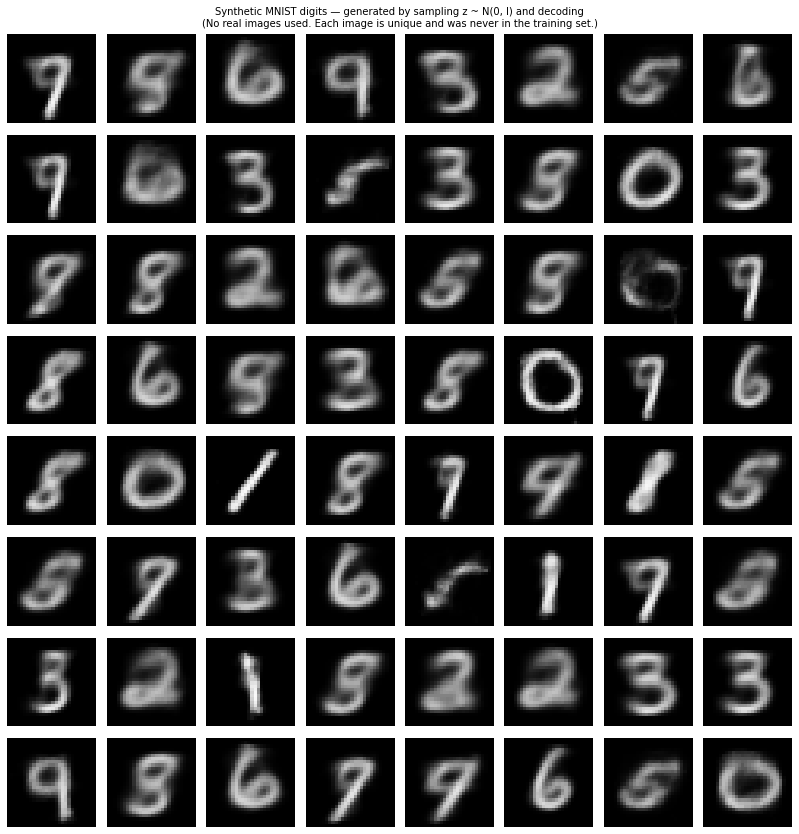

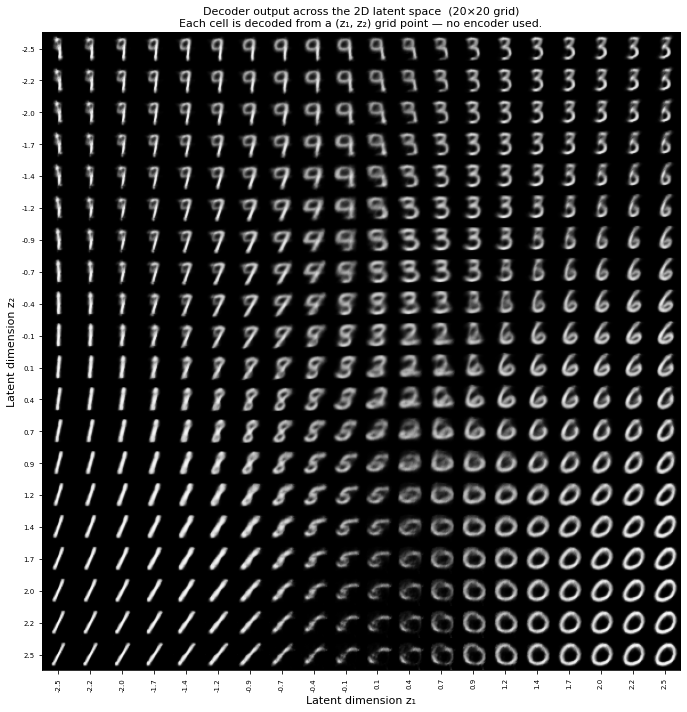

In [11]:
# -------------------------------------------------------
# Part A: random samples from the prior N(0, I)
# -------------------------------------------------------

def plot_generated_samples(model, n_samples=64, seed=0):
    """
    Generate synthetic digits by sampling z ~ N(0, I) and decoding.
    No encoder is used — these images are entirely new inventions.
    """
    torch.manual_seed(seed)
    model.eval()

    with torch.no_grad():
        # Sample latent vectors from the prior distribution
        z = torch.randn(n_samples, model.latent_dim)   # shape: (n_samples, 2)

        # Decode each latent vector to a 784-pixel image
        generated = model.decoder(z)                   # shape: (n_samples, 784)
        generated = generated.view(n_samples, 28, 28).numpy()

    n_cols = 8
    n_rows = n_samples // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 1.4, n_rows * 1.4 + 0.6))

    for idx, ax in enumerate(axes.flat):
        ax.imshow(generated[idx], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

    plt.suptitle(
        f'Synthetic MNIST digits — generated by sampling z ~ N(0, I) and decoding\n'
        f'(No real images used. Each image is unique and was never in the training set.)',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


plot_generated_samples(vae, n_samples=64)


# -------------------------------------------------------
# Part B: 2D grid scan of the latent space
# -------------------------------------------------------

def plot_latent_grid(model, n_grid=20, z_range=2.5):
    """
    Sweep z1 and z2 over a regular grid and decode each point.
    This directly maps out what the decoder has learned.

    z_range controls how far from the origin we scan.
    Values beyond ~2–3 are in the tails of N(0,1) and may produce
    less defined outputs (the decoder was rarely trained there).
    """
    model.eval()
    grid_size = 28 * n_grid   # total pixel canvas size
    canvas = np.zeros((grid_size, grid_size))

    # Linearly spaced values from -z_range to +z_range along each axis.
    z_values = np.linspace(-z_range, z_range, n_grid)

    with torch.no_grad():
        for i, z2 in enumerate(z_values):
            for j, z1 in enumerate(z_values):
                z = torch.tensor([[z1, z2]], dtype=torch.float32)
                img = model.decoder(z).view(28, 28).numpy()
                row = i * 28
                col = j * 28
                canvas[row:row+28, col:col+28] = img

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(canvas, cmap='gray', vmin=0, vmax=1)
    ax.set_xticks(np.arange(n_grid) * 28 + 14)
    ax.set_yticks(np.arange(n_grid) * 28 + 14)
    ax.set_xticklabels([f'{v:.1f}' for v in z_values], rotation=90, fontsize=7)
    ax.set_yticklabels([f'{v:.1f}' for v in z_values], fontsize=7)
    ax.set_xlabel('Latent dimension z₁', fontsize=11)
    ax.set_ylabel('Latent dimension z₂', fontsize=11)
    ax.set_title(
        f'Decoder output across the 2D latent space  ({n_grid}×{n_grid} grid)\n'
        'Each cell is decoded from a (z₁, z₂) grid point — no encoder used.',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


plot_latent_grid(vae, n_grid=20)

## 13. Latent Space Interpolation

Because the VAE's latent space is continuous and well-structured, we can **walk in a straight line** from one image's latent code to another's, decoding at each step. The result is a smooth morphing sequence between two digits.

A plain autoencoder (without the variational regularisation) cannot do this reliably — the space between two encoded points may contain unexplored, decoder-unfamiliar territory, producing garbled outputs midway. The KL term fills in those gaps.

This is directly analogous to interpolating between two parameter estimates on a smooth posterior surface, rather than jumping between two isolated MAP solutions.

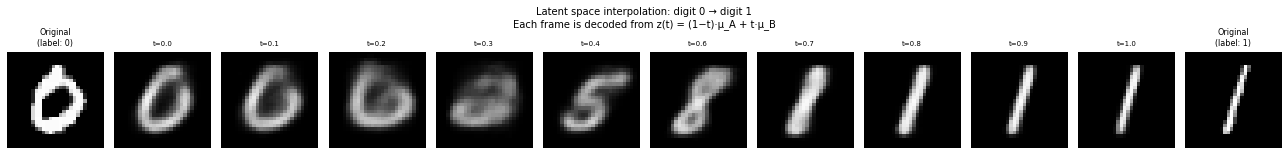

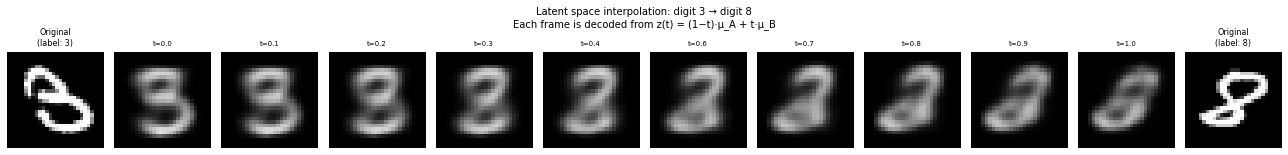

In [12]:
def interpolate(model, dataset, idx_a=0, idx_b=1, n_steps=10):
    """
    Encode two images to their latent means, linearly interpolate between them,
    and decode each point along the path.

    Parameters
    ----------
    idx_a, idx_b : indices into `dataset` — the two images to interpolate between
    n_steps      : number of intermediate steps (including endpoints)
    """
    model.eval()
    img_a, label_a = dataset[idx_a]
    img_b, label_b = dataset[idx_b]

    with torch.no_grad():
        mu_a, _ = model.encoder(img_a.unsqueeze(0))
        mu_b, _ = model.encoder(img_b.unsqueeze(0))

    # Linear interpolation: z(t) = (1-t)*mu_a + t*mu_b for t in [0, 1]
    steps  = torch.linspace(0, 1, n_steps)
    zs     = [(1 - t) * mu_a + t * mu_b for t in steps]
    zs     = torch.cat(zs, dim=0)   # (n_steps, latent_dim)

    with torch.no_grad():
        decoded = model.decoder(zs).view(n_steps, 28, 28).numpy()

    fig, axes = plt.subplots(1, n_steps + 2, figsize=((n_steps + 2) * 1.5, 2.2))

    # Left: original image A
    axes[0].imshow(unnormalise(img_a).squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Original\n(label: {label_a})', fontsize=8)
    axes[0].axis('off')

    # Interpolated frames
    for i in range(n_steps):
        axes[i + 1].imshow(decoded[i], cmap='gray', vmin=0, vmax=1)
        axes[i + 1].set_title(f't={steps[i]:.1f}', fontsize=7)
        axes[i + 1].axis('off')

    # Right: original image B
    axes[-1].imshow(unnormalise(img_b).squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[-1].set_title(f'Original\n(label: {label_b})', fontsize=8)
    axes[-1].axis('off')

    plt.suptitle(
        f'Latent space interpolation: digit {label_a} → digit {label_b}\n'
        f'Each frame is decoded from z(t) = (1−t)·μ_A + t·μ_B',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


# Find test images of two different digit classes to interpolate between.
# Change these indices to explore other pairs.
labels = [test_dataset[i][1] for i in range(200)]
idx_a = next(i for i, l in enumerate(labels) if l == 0)   # first '0'
idx_b = next(i for i, l in enumerate(labels) if l == 1)   # first '1'

interpolate(vae, test_dataset, idx_a=idx_a, idx_b=idx_b, n_steps=10)

# Also try a 3 → 8 interpolation (visually interesting)
idx_c = next(i for i, l in enumerate(labels) if l == 3)
idx_d = next(i for i, l in enumerate(labels) if l == 8)
interpolate(vae, test_dataset, idx_a=idx_c, idx_b=idx_d, n_steps=10)

## 14. Effect of Latent Dimension

We have been using `latent_dim=2` to make the latent space directly visualisable. But 2 dimensions is an extreme compression — a 28×28 image has 784 pixels and a VAE with `latent_dim=2` has a **compression ratio of 392:1**.

Here we train three VAEs with different latent dimensions and compare:
- **Reconstruction quality**: shown by the BCE reconstruction loss (lower is better)
- **Generated sample quality**: visual comparison of random samples

The trade-off is straightforward: larger latent dimension → better reconstructions (more information preserved) → but the latent space is no longer directly visualisable, and generation requires more structure to have been learned.

**This cell trains 3 models (2, 8, 32 dimensions × 10 epochs) and takes several minutes.**


--- latent_dim = 2 ---
Epoch  1/10  |  Total: 183.4  Recon: 176.9  KL: 6.46  | 13.7s
Epoch  2/10  |  Total: 165.4  Recon: 160.0  KL: 5.35  | 13.8s
Epoch  3/10  |  Total: 161.8  Recon: 156.3  KL: 5.49  | 13.9s
Epoch  4/10  |  Total: 159.6  Recon: 154.0  KL: 5.57  | 14.0s
Epoch  5/10  |  Total: 158.0  Recon: 152.4  KL: 5.66  | 13.8s
Epoch  6/10  |  Total: 156.7  Recon: 151.0  KL: 5.72  | 13.8s
Epoch  7/10  |  Total: 155.6  Recon: 149.9  KL: 5.77  | 13.8s
Epoch  8/10  |  Total: 154.7  Recon: 148.9  KL: 5.84  | 13.8s
Epoch  9/10  |  Total: 154.0  Recon: 148.1  KL: 5.89  | 14.0s
Epoch 10/10  |  Total: 153.3  Recon: 147.4  KL: 5.92  | 14.2s

--- latent_dim = 8 ---
Epoch  1/10  |  Total: 149.9  Recon: 134.9  KL: 14.94  | 14.2s
Epoch  2/10  |  Total: 126.3  Recon: 111.6  KL: 14.70  | 14.0s
Epoch  3/10  |  Total: 122.6  Recon: 107.6  KL: 14.97  | 14.0s
Epoch  4/10  |  Total: 120.6  Recon: 105.3  KL: 15.24  | 13.9s
Epoch  5/10  |  Total: 119.0  Recon: 103.6  KL: 15.40  | 13.9s
Epoch  6/10  |  T

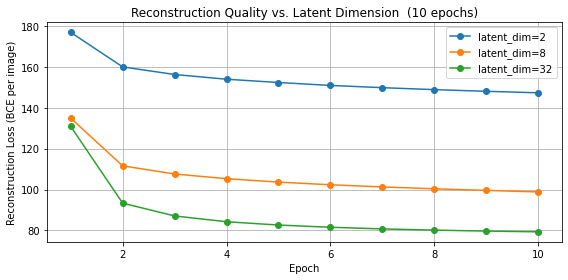

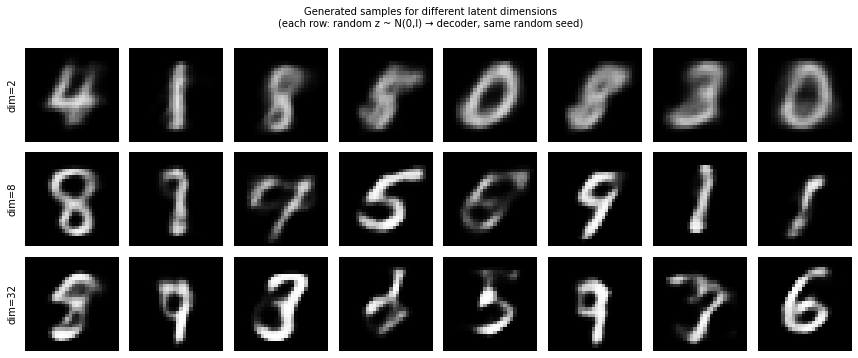


latent_dim        Final recon loss
--------------------------------------------------
2                            147.4
8                             98.8
32                            79.3


In [13]:
latent_dims   = [2, 8, 32]
dim_models    = {}
dim_recon_losses = {}

for ld in latent_dims:
    print(f"\n--- latent_dim = {ld} ---")
    m = VAE(latent_dim=ld, hidden_dim=512)
    # 10 epochs here to keep runtime reasonable;
    # the relative ordering stabilises quickly
    _, r_losses, _ = train_vae(m, train_loader, n_epochs=10)
    dim_models[ld]       = m
    dim_recon_losses[ld] = r_losses

# --- Plot reconstruction loss curves ---
plt.figure(figsize=(8, 4))
for ld in latent_dims:
    plt.plot(range(1, 11), dim_recon_losses[ld], '-o', label=f'latent_dim={ld}')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (BCE per image)')
plt.title('Reconstruction Quality vs. Latent Dimension  (10 epochs)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Visual comparison: random samples from each model ---
n_show = 8
fig, axes = plt.subplots(len(latent_dims), n_show,
                         figsize=(n_show * 1.5, len(latent_dims) * 1.7))

torch.manual_seed(42)
for row, ld in enumerate(latent_dims):
    model = dim_models[ld]
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_show, ld)
        imgs = model.decoder(z).view(n_show, 28, 28).numpy()
    for col in range(n_show):
        axes[row, col].imshow(imgs[col], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    # axis('off') suppresses set_ylabel, so use text() instead
    axes[row, 0].text(-0.08, 0.5, f'dim={ld}',
                      transform=axes[row, 0].transAxes,
                      fontsize=10, ha='right', va='center', rotation=90)

plt.suptitle(
    'Generated samples for different latent dimensions\n'
    '(each row: random z ~ N(0,I) → decoder, same random seed)',
    fontsize=10
)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*50)
print(f"{'latent_dim':<15} {'Final recon loss':>18}")
print("-"*50)
for ld in latent_dims:
    print(f"{ld:<15} {dim_recon_losses[ld][-1]:>18.1f}")
print("="*50)

## Summary

In this notebook we:

1. **Motivated the VAE** from a physics perspective — nonlinear dimensionality reduction (generalised PCA) combined with Bayesian probabilistic inference over latent codes.
2. **Built the encoder and decoder** as symmetric MLP networks, with the encoder outputting a Gaussian distribution $(\boldsymbol{\mu}, \log \boldsymbol{\sigma}^2)$ rather than a single point.
3. **Implemented the reparameterization trick** — moving randomness into a fixed external noise input so gradients can flow back through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$.
4. **Derived and coded the ELBO loss** — reconstruction (BCE) pulling toward accurate decoding, KL divergence pushing the encoder toward a standard normal prior.
5. **Visualised reconstructions** — seeing the information loss from compressing 784 pixels to just 2 numbers.
6. **Mapped the 2D latent space** — digit classes organise into distinct regions of a unit-ish disk, purely from self-supervised training.
7. **Generated brand-new synthetic digits using only the decoder** — sampling $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decoding, with no encoder or real images involved.
8. **Interpolated between digits** — smooth morphing shows the latent space is continuous and well-structured throughout.
9. **Compared latent dimensions** — larger latent spaces give sharper reconstructions at the cost of losing direct visualisability.

### The key lesson

The VAE is a generative model, not just a compressor. The KL regularisation term is the ingredient that makes generation work: by forcing the encoder to keep its posteriors close to a standard normal prior, it ensures the decoder has learned to handle the entire unit Gaussian ball, not just the isolated points where training images happened to land. Sampling anywhere in that ball produces something meaningful.

This is an instance of a very general principle: a good generative model must have a well-structured latent space where nearby points correspond to similar outputs. Building in the right prior — here, $\mathcal{N}(\mathbf{0}, \mathbf{I})$ — is what creates that structure.

### Things to try
- Change `latent_dim` to 3 in the main VAE and use a 3D scatter plot (`ax.scatter3D`) to visualise the latent space.
- In the latent grid plot (`plot_latent_grid`), change `z_range` — what happens beyond ±3? Why?
- Try `hidden_dim=128` — does a smaller network still learn a reasonable latent space?
- Change `idx_a` and `idx_b` in the interpolation cell to find pairs where the morphing produces interesting intermediate shapes.
- Try setting `seed` in `plot_generated_samples` to different values — how much does the visual quality vary?